In [2]:
# Импорт библиотек
import os
import torch
import torch.nn as nn
import numpy as np
import matplotlib
import random
from torch.utils.data import DataLoader, random_split
import torch.optim as optim
import matplotlib.pyplot as plt

# Датасеты / трансформации
from torchvision import transforms, datasets
import torchvision

print("torch:", torch.__version__)
print("torchvision:", torchvision.__version__)

# Фиксирую seed

def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)
# Размер батча подстроим под наличие GPU
BATCH_SIZE = 256 if device.type == "cuda" else 64

torch: 2.6.0+cu124
torchvision: 0.21.0+cu124
device: cuda


In [3]:
# На Windows в Jupyter иногда бывают проблемы с multiprocessing в DataLoader.
# Поэтому автоматически ставим num_workers=0 на Windows, иначе 2.
NUM_WORKERS = 0 if os.name == "nt" else 2
# Трансформации: ToTensor и Normalize
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Скачиваем датасет
train_full = torchvision.datasets.EMNIST(
    root = "./data", split = "balanced", train = True, download = True, transform = transform
)
test_ds = torchvision.datasets.EMNIST(
    root = "./data", split = "balanced", train = False, download = True, transform = transform
)

class_names = train_full.classes
print("classes:", class_names)
print("train_size:", len(train_full))
print("test_size:", len(test_ds))

# train/val split
val_ratio = 0.1
val_size = int(len(train_full) * val_ratio)
train_size = len(train_full) - val_size

gen = torch.Generator().manual_seed(42)
train_ds, val_ds = random_split(train_full, [train_size, val_size], generator=gen)

# DataLoader

train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=(device.type == "cuda")
)
val_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=(device.type == "cuda")
)
test_loader = DataLoader(
    test_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=(device.type == "cuda")
)

# sanity-check
x_batch, y_batch = next(iter(train_loader))
print("x_batch:", x_batch.shape, x_batch.dtype)
print("y_batch:", y_batch.shape, y_batch.dtype)

classes: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'a', 'b', 'd', 'e', 'f', 'g', 'h', 'n', 'q', 'r', 't']
train_size: 112800
test_size: 18800
x_batch: torch.Size([256, 1, 28, 28]) torch.float32
y_batch: torch.Size([256]) torch.int64


In [4]:
class MLP(nn.Module):
    def __init__(
        self,
        input_dim: int = 28*28,
        hidden_dims: tuple = (256, 128),
        num_classes: int = 47,
        activation: str = "relu",
        dropout_p: float = 0.0,
        use_batchnorm: bool = False,
    ):
        super().__init__()

        act = activation.lower()
        if act == "relu":
            act_layer = nn.ReLU
        elif act == "tanh":
            act_layer = nn.Tanh
        elif act == "gelu":
            act_layer = nn.GELU
        else:
            raise ValueError(f"Uknown activation: {activation}")

        layers = [nn.Flatten()]

        prev = input_dim
        for h in hidden_dims:
            layers.append(nn.Linear(prev, h))
            if use_batchnorm:
                layers.append(nn.BatchNorm1d(h))
            layers.append(act_layer())
            if dropout_p > 0:
                layers.append(nn.Dropout(p=dropout_p))
            prev = h

        layers.append(nn.Linear(prev, num_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

# sainty-check
model = MLP(dropout_p = 0.2, use_batchnorm = True).to(device)
with torch.no_grad():
    out = model(x_batch.to(device))
print("logists:", out.shape)

def accuracy_from_logits(logits: torch.Tensor, y_true: torch.Tensor) -> float:
    # Accuracy для классификации: logits -> argmax -> сравнение с y_true.
    preds = torch.argmax(logits, dim=1)
    return (preds == y_true).float().mean().item()
        
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()  # включаем train-режим (Dropout/BatchNorm!)
    total_loss = 0.0
    total_acc = 0.0
    n_batches = 0

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        logits = model(x)
        loss = criterion(logits, y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_acc += accuracy_from_logits(logits, y)
        n_batches += 1
    return total_loss / n_batches, total_acc / n_batches


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()  # включаем eval-режим (Dropout/BatchNorm!)
    total_loss = 0.0
    total_acc = 0.0
    n_batches = 0

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        logits = model(x)
        loss = criterion(logits, y)

        total_loss += loss.item()
        total_acc += accuracy_from_logits(logits, y)
        n_batches += 1

    return total_loss / n_batches, total_acc / n_batches
    
class EarlyStopping:
    def __init__(self, patience: int = 5, min_delta: float = 0.0):
        self.patience = patience
        self.min_delta = min_delta
        self.best_score = None
        self.best_state = None
        self.counter = 0

    def step(self, score: float, model: nn.Module) -> bool:
        # score: чем больше, тем лучше (например, val_acc).
        # Возвращает True, если нужно остановиться.
        if self.best_score is None:
            self.best_score = score
            self.best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            return False

        if score > self.best_score + self.min_delta:
            self.best_score = score
            self.best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            self.counter = 0
            return False

        self.counter += 1
        return self.counter >= self.patience

    def restore_best(self, model: nn.Module) -> None:
        if self.best_state is not None:
            model.load_state_dict(self.best_state)


model = MLP(dropout_p=0.2, use_batchnorm=True).to(device)
with torch.no_grad():
    out = model(x_batch.to(device))
print("logits:", out.shape)

def plot_history(history: dict, title: str = "") -> None:
    # history ожидается вида:
    # {
    #   "train_loss": [...], "val_loss": [...],
    #   "train_acc": [...],  "val_acc": [...]
    # }
    epochs = np.arange(1, len(history["train_loss"]) + 1)

    plt.figure()
    plt.plot(epochs, history["train_loss"], label="train_loss")
    plt.plot(epochs, history["val_loss"], label="val_loss")
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.title((title + " (loss)") if title else "loss")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure()
    plt.plot(epochs, history["train_acc"], label="train_acc")
    plt.plot(epochs, history["val_acc"], label="val_acc")
    plt.xlabel("epoch")
    plt.ylabel("accuracy")
    plt.title((title + " (accuracy)") if title else "accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()

def fit(
    model,
    train_loader,
    val_loader,
    optimizer,
    criterion,
    device,
    epochs: int = 20,
    early_stopping=None,
    verbose: bool = True,
):
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
        va_loss, va_acc = evaluate(model, val_loader, criterion, device)

        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(va_loss)
        history["val_acc"].append(va_acc)

        if verbose:
            print(
                f"epoch {epoch:02d}/{epochs} | "
                f"train loss={tr_loss:.4f}, acc={tr_acc:.4f} | "
                f"val loss={va_loss:.4f}, acc={va_acc:.4f}"
            )

        if early_stopping is not None:
            should_stop = early_stopping.step(va_acc, model)
            if should_stop:
                if verbose:
                    print(
                        f"EarlyStopping: остановка на эпохе {epoch}. "
                        f"Лучший val_acc={early_stopping.best_score:.4f}"
                    )
                early_stopping.restore_best(model)
                break

    return history

logists: torch.Size([256, 47])
logits: torch.Size([256, 47])


epoch 01/12 | train loss=1.5898, acc=0.5640 | val loss=1.1003, acc=0.6815
epoch 02/12 | train loss=0.9565, acc=0.7167 | val loss=0.8631, acc=0.7470
epoch 03/12 | train loss=0.7776, acc=0.7636 | val loss=0.7463, acc=0.7714
epoch 04/12 | train loss=0.6863, acc=0.7861 | val loss=0.6715, acc=0.7942
epoch 05/12 | train loss=0.6295, acc=0.8001 | val loss=0.6391, acc=0.7985
epoch 06/12 | train loss=0.5906, acc=0.8094 | val loss=0.6182, acc=0.8069
epoch 07/12 | train loss=0.5622, acc=0.8180 | val loss=0.5917, acc=0.8125
epoch 08/12 | train loss=0.5391, acc=0.8231 | val loss=0.5827, acc=0.8136
epoch 09/12 | train loss=0.5213, acc=0.8287 | val loss=0.5827, acc=0.8128
epoch 10/12 | train loss=0.5036, acc=0.8337 | val loss=0.5672, acc=0.8179
epoch 11/12 | train loss=0.4892, acc=0.8372 | val loss=0.5485, acc=0.8242
epoch 12/12 | train loss=0.4779, acc=0.8389 | val loss=0.5353, acc=0.8276


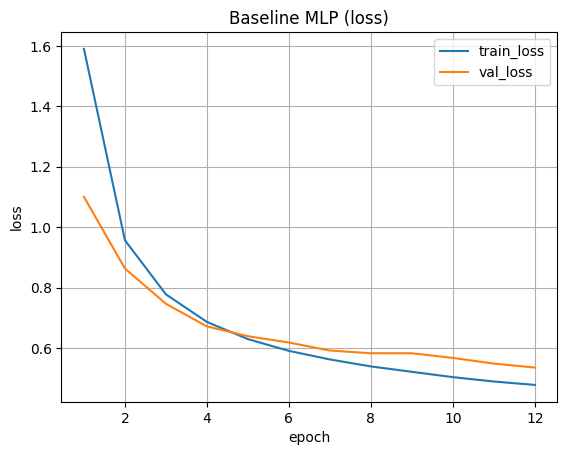

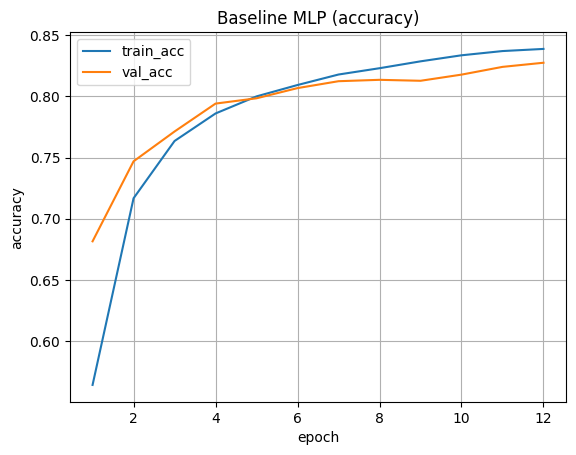

In [5]:
# Эксперименты:

# E1: baseline
set_seed(42)
baseline = MLP(hidden_dims=(128, 64), dropout_p=0.0, use_batchnorm=False).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(baseline.parameters(), lr=1e-3)

history_baseline = fit(
    baseline, train_loader, val_loader,
    optimizer, criterion, device,
    epochs=12,
    early_stopping=None
)

plot_history(history_baseline, title="Baseline MLP")

In [6]:
# E2: Dropout
set_seed(42)
model_e2 = MLP(hidden_dims=(128, 64), dropout_p=0.3, use_batchnorm=False).to(device)
optimizer_e2 = optim.Adam(model_e2.parameters(), lr=1e-3)
history_e2 = fit(
    model_e2, train_loader, val_loader,
    optimizer_e2, criterion, device,
    epochs=12,
    early_stopping=None
)

print(f" E2 finished Best val_acc: {max(history_e2['val_acc']):.2f}%")

epoch 01/12 | train loss=2.1428, acc=0.4029 | val loss=1.2126, acc=0.6528
epoch 02/12 | train loss=1.4805, acc=0.5620 | val loss=1.0176, acc=0.7025
epoch 03/12 | train loss=1.3412, acc=0.6002 | val loss=0.9323, acc=0.7245
epoch 04/12 | train loss=1.2620, acc=0.6198 | val loss=0.8785, acc=0.7369
epoch 05/12 | train loss=1.2137, acc=0.6318 | val loss=0.8328, acc=0.7516
epoch 06/12 | train loss=1.1757, acc=0.6423 | val loss=0.8120, acc=0.7538
epoch 07/12 | train loss=1.1453, acc=0.6507 | val loss=0.7877, acc=0.7619
epoch 08/12 | train loss=1.1237, acc=0.6560 | val loss=0.7651, acc=0.7624
epoch 09/12 | train loss=1.0977, acc=0.6616 | val loss=0.7642, acc=0.7649
epoch 10/12 | train loss=1.0824, acc=0.6671 | val loss=0.7364, acc=0.7732
epoch 11/12 | train loss=1.0655, acc=0.6713 | val loss=0.7255, acc=0.7748
epoch 12/12 | train loss=1.0580, acc=0.6730 | val loss=0.7227, acc=0.7817
 E2 finished Best val_acc: 0.78%


In [7]:
# E3: BatchNorm
set_seed(42)
model_e3 = MLP(hidden_dims=(128, 64), dropout_p = 0.0, use_batchnorm = True).to(device)
optimizer_e3 = optim.Adam(model_e3.parameters(), lr=1e-3)
history_e3 = fit(
    model_e3, train_loader, val_loader,
    optimizer_e3, criterion, device,
    epochs=12,
    early_stopping=None
)

print(f" E3 finished Best val_acc: {max(history_e3['val_acc']):.2f}%")

epoch 01/12 | train loss=1.4159, acc=0.6679 | val loss=0.7746, acc=0.7704
epoch 02/12 | train loss=0.6422, acc=0.8025 | val loss=0.6070, acc=0.8141
epoch 03/12 | train loss=0.5280, acc=0.8282 | val loss=0.5655, acc=0.8217
epoch 04/12 | train loss=0.4752, acc=0.8410 | val loss=0.5367, acc=0.8262
epoch 05/12 | train loss=0.4417, acc=0.8497 | val loss=0.5158, acc=0.8305
epoch 06/12 | train loss=0.4148, acc=0.8575 | val loss=0.5143, acc=0.8347
epoch 07/12 | train loss=0.3973, acc=0.8618 | val loss=0.5081, acc=0.8332
epoch 08/12 | train loss=0.3794, acc=0.8666 | val loss=0.5141, acc=0.8346
epoch 09/12 | train loss=0.3653, acc=0.8712 | val loss=0.4997, acc=0.8358
epoch 10/12 | train loss=0.3529, acc=0.8740 | val loss=0.5043, acc=0.8361
epoch 11/12 | train loss=0.3415, acc=0.8775 | val loss=0.4972, acc=0.8352
epoch 12/12 | train loss=0.3331, acc=0.8800 | val loss=0.4938, acc=0.8418
 E3 finished Best val_acc: 0.84%


In [8]:
# Сравниваем E2 и E3 по показателю val_accuracy
best_val_acc_e2 = max(history_e2["val_acc"])
best_val_acc_e3 = max(history_e3["val_acc"])

if best_val_acc_e2 >= best_val_acc_e3:
    print("Выбрана модель с Dropout (E2) для E4")
    best_model_class = lambda: MLP(hidden_dims=(128, 64), dropout_p=0.3, use_batchnorm=False)
else:
    print("Выбрана модель с BatchNorm (E3) для E4")
    best_model_class = lambda: MLP(hidden_dims=(128, 64), dropout_p=0.0, use_batchnorm=True)

# E4: EarlyStopping
set_seed(42)
model_e4 = best_model_class().to(device)
optimizer_e4 = optim.Adam(model_e4.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()  # ← добавьте явно

history_e4 = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

patience = 5
best_val_acc = 0.0
best_epoch = 0
epochs_without_improvement = 0
max_epochs = 30

print(f"Training with EarlyStopping (patience={patience})...")

for epoch in range(max_epochs):
    train_loss, train_acc = train_one_epoch(model_e4, train_loader, optimizer_e4, criterion, device)
    val_loss, val_acc = evaluate(model_e4, val_loader, criterion, device)
    
    history_e4['train_loss'].append(train_loss)
    history_e4['train_acc'].append(train_acc)
    history_e4['val_loss'].append(val_loss)
    history_e4['val_acc'].append(val_acc)
    
    print(f"Epoch {epoch+1} | Train: {train_loss:.4f}/{train_acc*100:.2f}% | Val: {val_loss:.4f}/{val_acc*100:.2f}%")
    
    # Сохраняем лучшую модель по val_acc
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_epoch = epoch + 1
        epochs_without_improvement = 0
        
        torch.save(model_e4.state_dict(), 'artifacts/best_model.pt')
        print(f" New best! Model saved to artifacts/best_model.pt")
    else:
        epochs_without_improvement += 1
    
    # Ранняя остановка
    if epochs_without_improvement >= patience:
        print(f"EarlyStopping triggered at epoch {epoch+1}. Best: epoch {best_epoch} ({best_val_acc*100:.2f}%)")
        break

# Обрезаем историю (на случай, если обучение прервалось)
actual_epochs = len(history_e4['val_acc'])
for key in history_e4:
    history_e4[key] = history_e4[key][:actual_epochs]

print(f"E4 finished! Best val_acc: {best_val_acc*100:.2f}% at epoch {best_epoch}")

Выбрана модель с BatchNorm (E3) для E4
Training with EarlyStopping (patience=5)...
Epoch 1 | Train: 1.4159/66.79% | Val: 0.7746/77.04%
 New best! Model saved to artifacts/best_model.pt
Epoch 2 | Train: 0.6422/80.25% | Val: 0.6070/81.41%
 New best! Model saved to artifacts/best_model.pt
Epoch 3 | Train: 0.5280/82.82% | Val: 0.5655/82.17%
 New best! Model saved to artifacts/best_model.pt
Epoch 4 | Train: 0.4752/84.10% | Val: 0.5367/82.62%
 New best! Model saved to artifacts/best_model.pt
Epoch 5 | Train: 0.4417/84.97% | Val: 0.5158/83.05%
 New best! Model saved to artifacts/best_model.pt
Epoch 6 | Train: 0.4148/85.75% | Val: 0.5143/83.47%
 New best! Model saved to artifacts/best_model.pt
Epoch 7 | Train: 0.3973/86.18% | Val: 0.5081/83.32%
Epoch 8 | Train: 0.3794/86.66% | Val: 0.5141/83.46%
Epoch 9 | Train: 0.3653/87.12% | Val: 0.4997/83.58%
 New best! Model saved to artifacts/best_model.pt
Epoch 10 | Train: 0.3529/87.40% | Val: 0.5043/83.61%
 New best! Model saved to artifacts/best_model

In [9]:
# Финальная оценка
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)
model_e4.eval()
test_acc = evaluate(model_e4, test_loader, criterion, device)[1]
print(f"Final test accuracy (E4): {test_acc:.4f}")

Final test accuracy (E4): 0.8365


best_config.json saved!


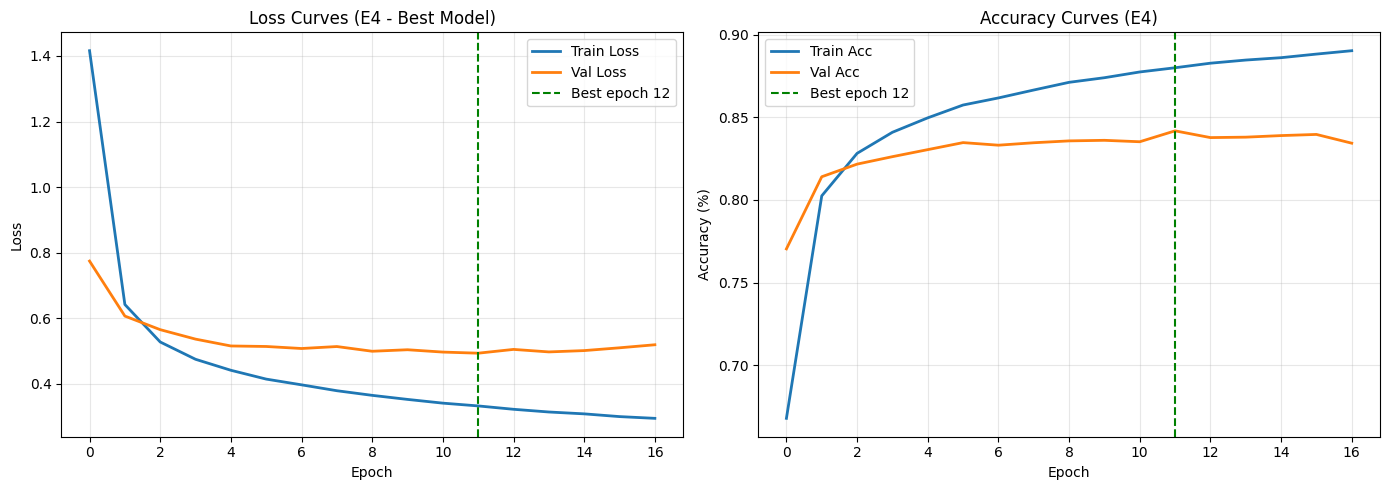

curves_best.png saved!


In [10]:
import json
import matplotlib.pyplot as plt

# 1. Сохраняем конфиг лучшей модели
config = {
    'dataset': 'EMNIST_balanced',
    'seed': 42,
    'model': {
        'type': 'MLP',
        'input_size': 28*28,
        'hidden_sizes': [128, 64],
        'num_classes': 47,
        'activation': 'ReLU',
        'dropout': 0.0,
        'use_bn': True
    },
    'optimizer': {
        'name': 'Adam',
        'lr': 1e-3
    },
    'early_stopping': {
        'patience': patience,
        'best_epoch': best_epoch,
        'best_val_accuracy': best_val_acc
    }
}

with open('artifacts/best_config.json', 'w') as f:
    json.dump(config, f, indent=2)
print("best_config.json saved!")

# 2. График curves_best.png
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(history_e4['train_loss'], label='Train Loss', linewidth=2)
axes[0].plot(history_e4['val_loss'], label='Val Loss', linewidth=2)
axes[0].axvline(x=best_epoch-1, color='green', linestyle='--', label=f'Best epoch {best_epoch}')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Loss Curves (E4 - Best Model)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(history_e4['train_acc'], label='Train Acc', linewidth=2)
axes[1].plot(history_e4['val_acc'], label='Val Acc', linewidth=2)
axes[1].axvline(x=best_epoch-1, color='green', linestyle='--', label=f'Best epoch {best_epoch}')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Accuracy Curves (E4)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('artifacts/figures/curves_best.png', dpi=150, bbox_inches='tight')
plt.show()
print("curves_best.png saved!")

In [11]:
# === O1: Слишком большой LR (Adam, lr=0.1) ===
set_seed(42)
model_o1 = best_model_class().to(device)  # та же архитектура, что и в E4
optimizer_o1 = optim.Adam(model_o1.parameters(), lr=0.5)  # ← lr=0.1
history_o1 = fit(
    model_o1, train_loader, val_loader,
    optimizer_o1, criterion, device,
    epochs=5,  # 5 эпох достаточно для демонстрации
    early_stopping=None
)
print(f"O1 finished. Best val_acc: {max(history_o1['val_acc']):.2f}%")

# === O2: Слишком маленький LR (Adam, lr=1e-5) ===
set_seed(42)
model_o2 = best_model_class().to(device)
optimizer_o2 = optim.Adam(model_o2.parameters(), lr=1e-5)  # ← lr=1e-5
history_o2 = fit(
    model_o2, train_loader, val_loader,
    optimizer_o2, criterion, device,
    epochs=5,
    early_stopping=None
)
print(f"O2 finished. Best val_acc: {max(history_o2['val_acc']):.2f}%")

# === O3: SGD+momentum + weight decay ===
set_seed(42)
model_o3 = best_model_class().to(device)
optimizer_o3 = optim.SGD(
    model_o3.parameters(),
    lr=0.01,  # ← разумный lr
    momentum=0.9,  # ← momentum
    weight_decay=1e-4  # ← weight decay
)
history_o3 = fit(
    model_o3, train_loader, val_loader,
    optimizer_o3, criterion, device,
    epochs=10,
    early_stopping=None
)
print(f"O3 finished. Best val_acc: {max(history_o3['val_acc']):.2f}%")

epoch 01/5 | train loss=2.7317, acc=0.2154 | val loss=2.1692, acc=0.3171
epoch 02/5 | train loss=2.0176, acc=0.3684 | val loss=1.9909, acc=0.3866
epoch 03/5 | train loss=1.8414, acc=0.4185 | val loss=1.7865, acc=0.4497
epoch 04/5 | train loss=1.7556, acc=0.4457 | val loss=1.7146, acc=0.4556
epoch 05/5 | train loss=1.6821, acc=0.4677 | val loss=1.8225, acc=0.4160
O1 finished. Best val_acc: 0.46%
epoch 01/5 | train loss=3.6982, acc=0.0884 | val loss=3.5048, acc=0.1653
epoch 02/5 | train loss=3.3816, acc=0.2278 | val loss=3.2675, acc=0.2796
epoch 03/5 | train loss=3.1852, acc=0.3193 | val loss=3.1053, acc=0.3563
epoch 04/5 | train loss=3.0364, acc=0.3857 | val loss=2.9710, acc=0.4127
epoch 05/5 | train loss=2.9112, acc=0.4364 | val loss=2.8532, acc=0.4583
O2 finished. Best val_acc: 0.46%
epoch 01/10 | train loss=1.5791, acc=0.6224 | val loss=0.8360, acc=0.7615
epoch 02/10 | train loss=0.7093, acc=0.7857 | val loss=0.6464, acc=0.8030
epoch 03/10 | train loss=0.5804, acc=0.8160 | val loss=0

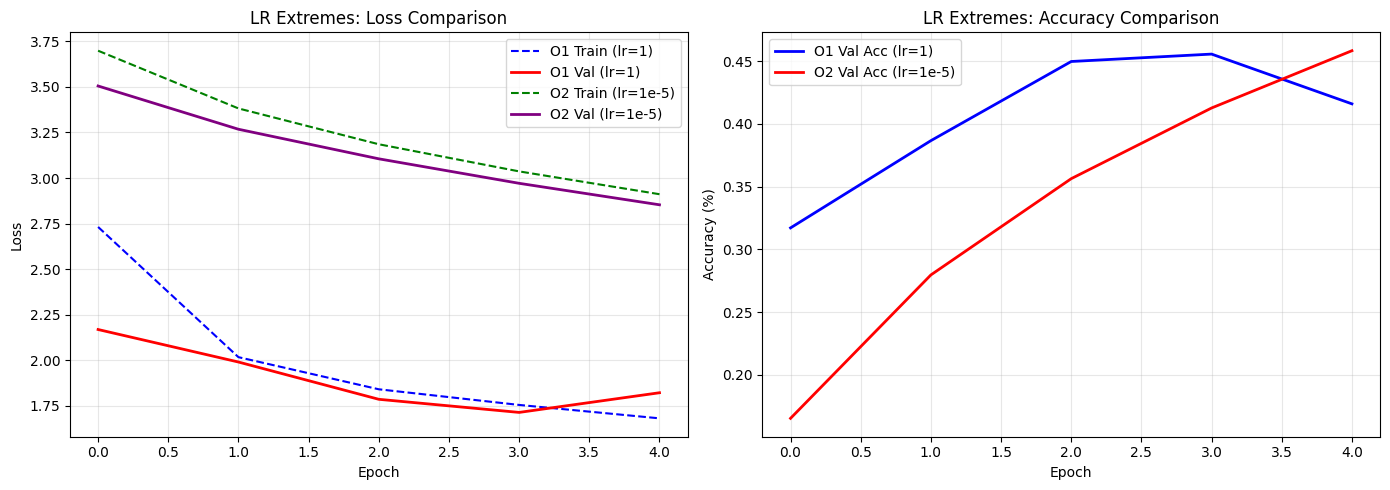

curves_lr_extremes.png saved!


In [12]:
# График для O1 и O2 (экстремальные LR)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(history_o1['train_loss'], label='O1 Train (lr=1)', linestyle='--', color='blue')
axes[0].plot(history_o1['val_loss'], label='O1 Val (lr=1)', linewidth=2, color='red')
axes[0].plot(history_o2['train_loss'], label='O2 Train (lr=1e-5)', linestyle='--', color='green')
axes[0].plot(history_o2['val_loss'], label='O2 Val (lr=1e-5)', linewidth=2, color='purple')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('LR Extremes: Loss Comparison')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(history_o1['val_acc'], label='O1 Val Acc (lr=1)', linewidth=2, color='blue')
axes[1].plot(history_o2['val_acc'], label='O2 Val Acc (lr=1e-5)', linewidth=2, color='red')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('LR Extremes: Accuracy Comparison')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('artifacts/figures/curves_lr_extremes.png', dpi=150, bbox_inches='tight')
plt.show()
print("curves_lr_extremes.png saved!")

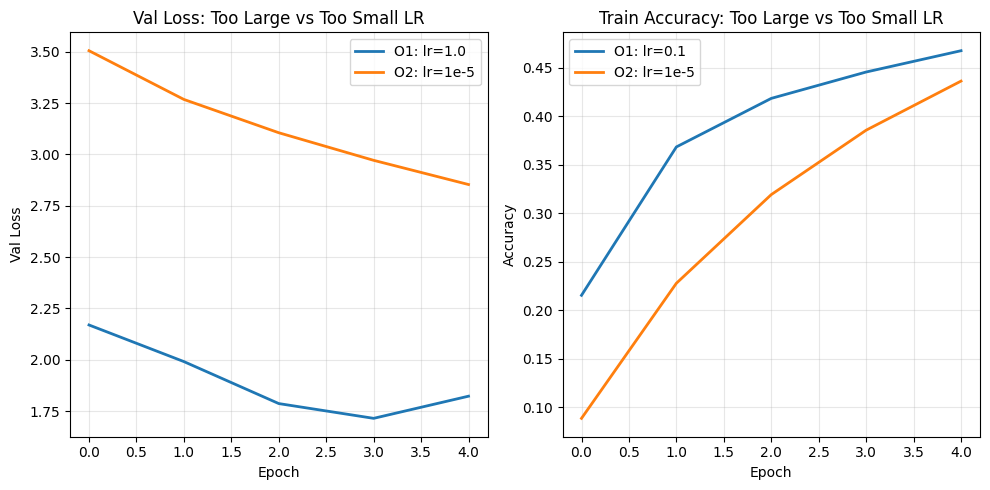

curves_lr_extremes.png saved!


In [13]:
# График поведения O1 и O2
plt.figure(figsize=(10, 5))

# Loss
plt.subplot(1, 2, 1)
plt.plot(history_o1["val_loss"], label="O1: lr=1.0", linewidth=2)
plt.plot(history_o2["val_loss"], label="O2: lr=1e-5", linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("Val Loss")
plt.title("Val Loss: Too Large vs Too Small LR")
plt.legend()
plt.grid(True, alpha=0.3)

# Accuracy
plt.subplot(1, 2, 2)
plt.plot(history_o1["train_acc"], label="O1: lr=0.1", linewidth=2)
plt.plot(history_o2["train_acc"], label="O2: lr=1e-5", linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Train Accuracy: Too Large vs Too Small LR")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("artifacts/figures/curves_lr_extremes.png", dpi=150, bbox_inches="tight")
plt.show()
print("curves_lr_extremes.png saved!")

runs.csv saved!
best_config.json saved!


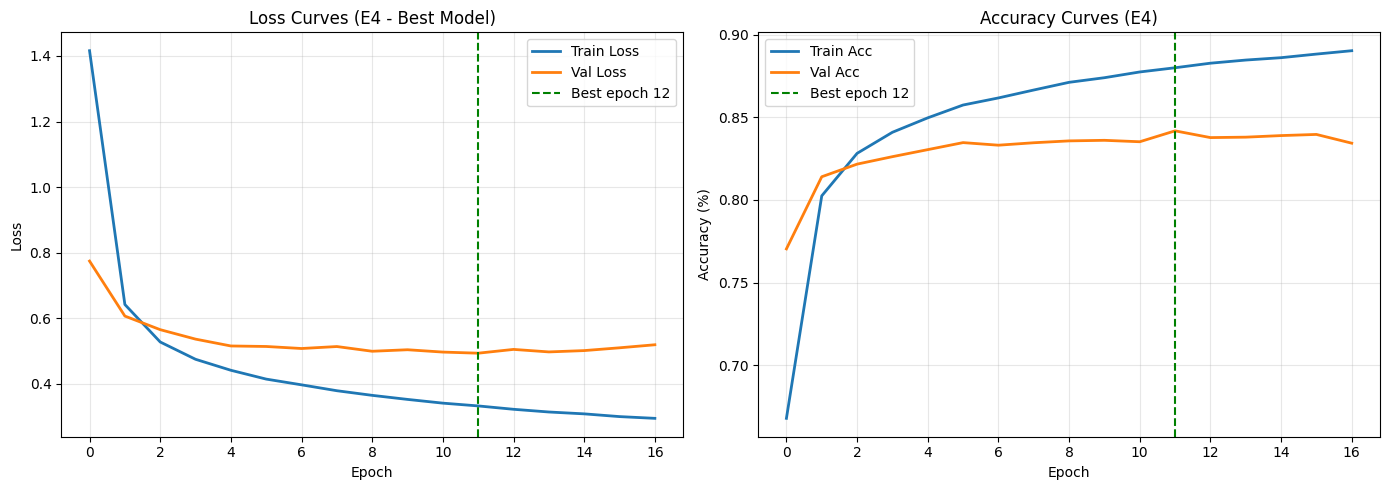

curves_best.png saved!


In [16]:
# Создание runs.csv

import pandas as pd
results = []

# E1-E4
for name, history in [
    ("E1", history_baseline),
    ("E2", history_e2),
    ("E3", history_e3),
    ("E4", history_e4)
]:
    results.append({
        "experiment_id": name,
        "dataset": "EMNIST_balanced",
        "seed": 42,
        "model_summary": "hidden=(128,64), dropout=0.3, bn=False" if "Dropout" in name else "hidden=(128,64), dropout=0.0, bn=True",
        "optimizer": "Adam",
        "lr": 0.001,
        "momentum": 0.0,
        "weight_decay": 0.0,
        "epochs_trained": len(history["train_loss"]),
        "best_val_accuracy": round(max(history["val_acc"]), 4),
        "best_val_loss": round(min(history["val_loss"]), 4)
    })

# O1-O3
for name, history, lr, mom, wd in [
    ("O1", history_o1, 1.0, 0.0, 0.0),
    ("O2", history_o2, 1e-5, 0.0, 0.0),
    ("O3", history_o3, 0.01, 0.9, 1e-4)
]:
    results.append({
        "experiment_id": name,
        "dataset": "EMNIST_balanced",
        "seed": 42,
        "model_summary": "hidden=(128,64), dropout=0.3, bn=False" if "Dropout" in name else "hidden=(128,64), dropout=0.0, bn=True",
        "optimizer": "SGD" if name == "O3" else "Adam",
        "lr": lr,
        "momentum": mom,
        "weight_decay": wd,
        "epochs_trained": len(history["train_loss"]),
        "best_val_accuracy": round(max(history["val_acc"]), 4),
        "best_val_loss": round(min(history["val_loss"]), 4)
    })

# Сохранение
df = pd.DataFrame(results)
df.to_csv("artifacts/runs.csv", index=False)
print("runs.csv saved!")

# best_config.json
import json

config = {
    'dataset': 'EMNIST_balanced',
    'seed': 42,
    'model': {
        'type': 'MLP',
        'input_size': 28*28,
        'hidden_sizes': [128, 64],
        'num_classes': 47,
        'activation': 'ReLU',
        'dropout': 0.0 if "BatchNorm" in best_model_class().__class__.__name__ else 0.3,
        'use_bn': "BatchNorm" in best_model_class().__class__.__name__
    },
    'optimizer': {
        'name': 'Adam',
        'lr': 1e-3
    },
    'early_stopping': {
        'patience': 5,
        'best_epoch': best_epoch,
        'best_val_accuracy': best_val_acc
    }
}

with open('artifacts/best_config.json', 'w') as f:
    json.dump(config, f, indent=2)
print("best_config.json saved!")

# curves_best.png
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(history_e4['train_loss'], label='Train Loss', linewidth=2)
axes[0].plot(history_e4['val_loss'], label='Val Loss', linewidth=2)
axes[0].axvline(x=best_epoch-1, color='green', linestyle='--', label=f'Best epoch {best_epoch}')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Loss Curves (E4 - Best Model)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(history_e4['train_acc'], label='Train Acc', linewidth=2)
axes[1].plot(history_e4['val_acc'], label='Val Acc', linewidth=2)
axes[1].axvline(x=best_epoch-1, color='green', linestyle='--', label=f'Best epoch {best_epoch}')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Accuracy Curves (E4)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('artifacts/figures/curves_best.png', dpi=150, bbox_inches='tight')
plt.show()
print("curves_best.png saved!")